In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False


import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# 데이터 가져오기

## 데이터 다운로드

In [2]:
from pathlib import Path
import tarfile
import urllib.request


def load_housing_data():
    tarball_path = Path('datasets/housing.tgz')
    if not tarball_path.is_file():
        Path('datasets').mkdir(parents=True, exist_ok=True)
        url = 'https://github.com/ageron/data/raw/main/housing.tgz'
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path='datasets')
    return pd.read_csv(Path('datasets/housing/housing.csv'))


housing = load_housing_data()

## 데이터 구조 훑어보기

In [3]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# 데이터 행, 열의 갯수 파악

housing.shape

(20640, 10)

In [5]:
# 데이터에 대한 간략한 설명(결측치, type 등을 알 수 있음)

housing.info()
# total_bedrooms에 결측치가 있음

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
# ocean_proximity가 어떤 값을 갖는지 확인

housing['ocean_proximity'].unique()
housing['ocean_proximity'].value_counts()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [7]:
# 수치형의 통계 정보를 확인

housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


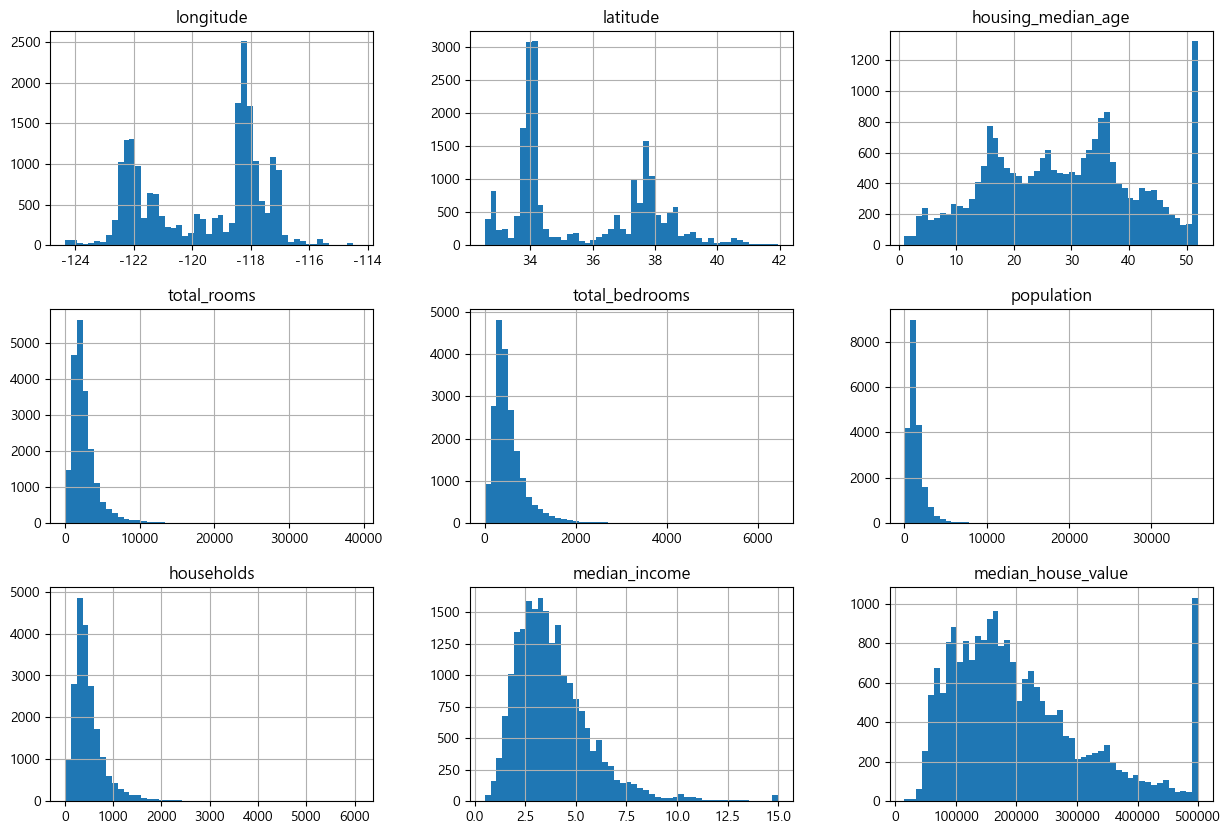

In [8]:
housing.hist(bins = 50, figsize = (15, 10));

## 테스트 세트 만들기

In [9]:
# 방법 1
# housing의 길이 중 인덱스를 랜덤으로 train, test를 정하는 방법


# def shuffle_and_split_data(data, test_ratio):
#     shuffled_indices = np.random.permutation(len(data))
#     test_set_size = int(len(data) * test_ratio)
#     test_indices = shuffled_indices[:test_set_size]
#     train_indices = shuffled_indices[test_set_size:]
#     return data.iloc[train_indices], data.iloc[test_indices]

In [10]:
# train_set, test_set = shuffle_and_split_data(housing, 0.2)
# len(train_set)
# len(test_set)

In [11]:
# 방법 2
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size = 0.2, random_state = 42)

In [12]:
train_set.shape

(16512, 10)

In [13]:
# pd.cut(x, bins, labels) : 구간 나누기

housing['income_cat'] = pd.cut(housing['median_income'],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

housing['income_cat']

0        5
1        5
2        5
3        4
4        3
        ..
20635    2
20636    2
20637    2
20638    2
20639    2
Name: income_cat, Length: 20640, dtype: category
Categories (5, int64): [1 < 2 < 3 < 4 < 5]

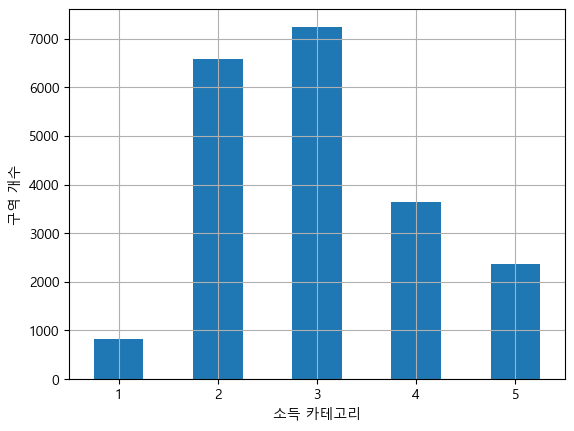

In [14]:
data = housing['income_cat'].value_counts().sort_index()
data.plot.bar(rot = 0, grid = True);
plt.xlabel('소득 카테고리');
plt.ylabel('구역 개수');

In [15]:
# 한 데이터셋으로 각각 다른 10개의 계층 분할
# 방법 1

# from sklearn.model_selection import StratifiedShuffleSplit

# splitter = StratifiedShuffleSplit(n_splits = 10, test_size = 0.2, random_state = 42,)
# strat_splits = []
# for train_index, test_index in splitter.split(housing, housing['income_cat']):
#     strat_train_set_n = housing.iloc[train_index]
#     strat_test_set_n = housing.iloc[test_index]
#     strat_splits.append([strat_train_set_n, strat_test_set_n])

# strat_train_set, strat_test_set = strat_splits[0]


# 방법 2

strat_train_set, strat_test_set = train_test_split(housing, test_size = 0.2, stratify = housing['income_cat'], random_state = 42)

In [16]:
strat_test_set['income_cat'].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [17]:
# income_cat 삭제

for set_ in (strat_train_set, strat_test_set):
    set_.drop('income_cat', axis = 1, inplace = True)

# 데이터 이해를 위해 탐색과 시각화

In [18]:
# housing 데이터를 income_cat을 계층적으로 나눈 데이터

housing = strat_train_set.copy()

## 지리적 데이터 시각화하기

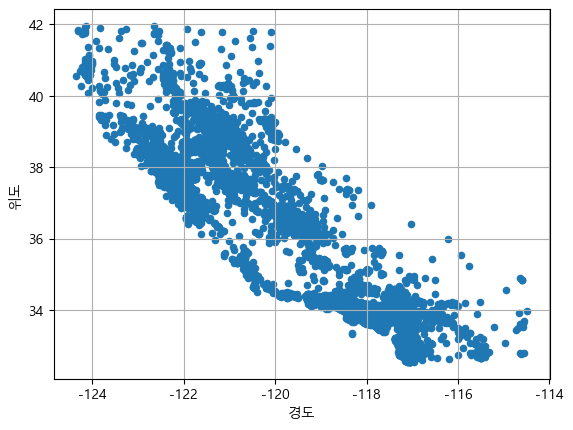

In [19]:
housing.plot(kind = 'scatter', x = 'longitude', y = 'latitude', grid = True);
plt.xlabel('경도');
plt.ylabel('위도');

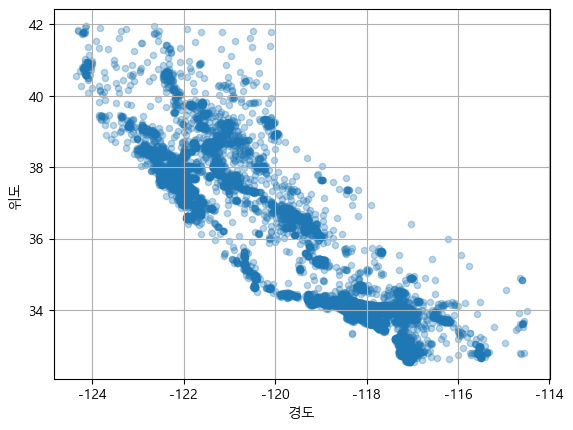

In [20]:
housing.plot(kind = 'scatter', x = 'longitude', y = 'latitude', grid = True, alpha = 0.3);
plt.xlabel('경도');
plt.ylabel('위도');

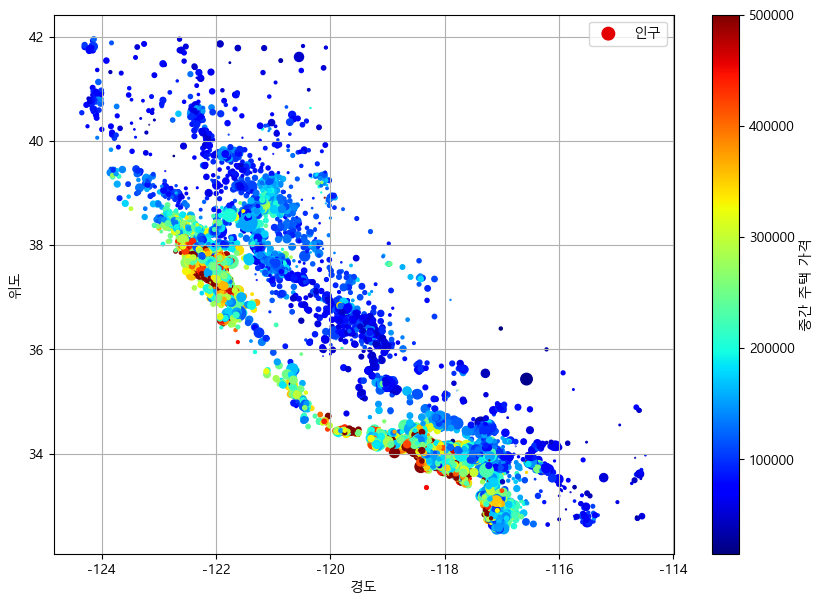

In [21]:
housing.plot(kind = 'scatter', x = 'longitude', y = 'latitude', grid = True,
            s = housing['population'] / 100, label = '인구',
            c = housing['median_house_value'], cmap = 'jet', colorbar = True,
            legend = True, sharex = True, figsize = (10, 7));

cax = plt.gcf().get_axes()[1];
cax.set_ylabel('중간 주택 가격');
plt.xlabel('경도');
plt.ylabel('위도');

## 상관관계 조사하기

In [22]:
corr_metrix = housing.corr(numeric_only = True)
corr_metrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924213,-0.102937,0.044558,0.068210,0.104236,0.054261,-0.016542,-0.050859
latitude,-0.924213,1.000000,0.005692,-0.036753,-0.066391,-0.115677,-0.071604,-0.078137,-0.139584
housing_median_age,-0.102937,0.005692,1.000000,-0.361710,-0.317978,-0.301906,-0.300075,-0.127043,0.102175
total_rooms,0.044558,-0.036753,-0.361710,1.000000,0.930076,0.863967,0.916143,0.197720,0.137455
total_bedrooms,0.068210,-0.066391,-0.317978,0.930076,1.000000,0.886200,0.978822,-0.006038,0.054635
population,0.104236,-0.115677,-0.301906,0.863967,0.886200,1.000000,0.916237,0.004282,-0.020153
households,0.054261,-0.071604,-0.300075,0.916143,0.978822,0.916237,1.000000,0.013637,0.071426
median_income,-0.016542,-0.078137,-0.127043,0.197720,-0.006038,0.004282,0.013637,1.000000,0.688380
median_house_value,-0.050859,-0.139584,0.102175,0.137455,0.054635,-0.020153,0.071426,0.688380,1.000000


In [23]:
corr_metrix['median_house_value'].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

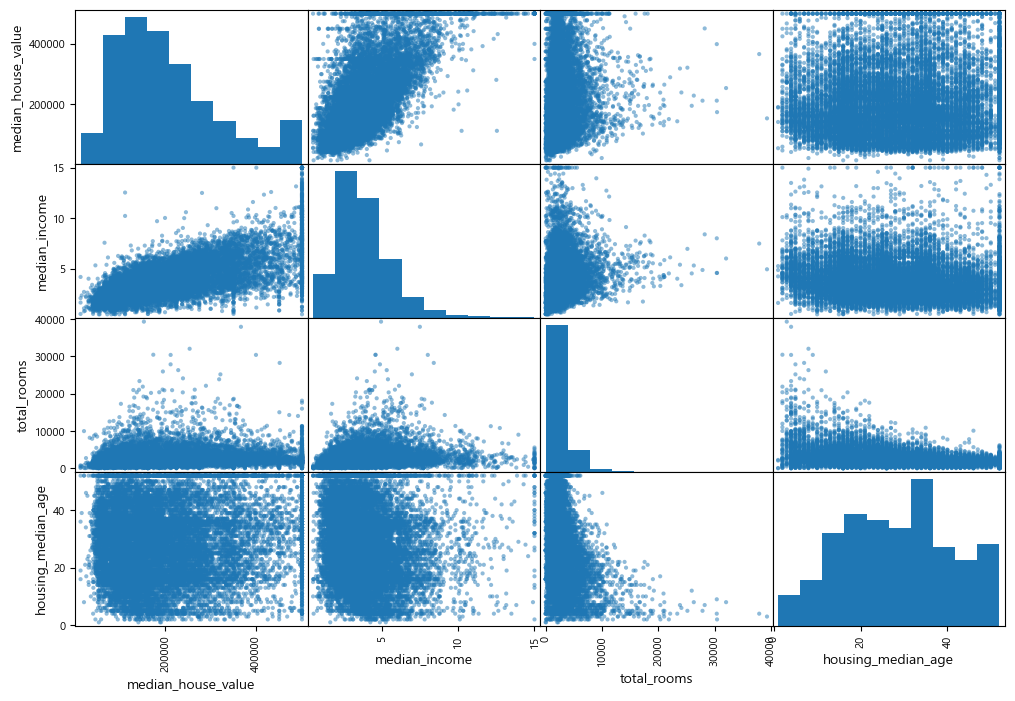

In [24]:
from pandas.plotting import scatter_matrix

attributes = ['median_house_value', 'median_income', 'total_rooms',
             'housing_median_age']

scatter_matrix(housing[attributes], figsize = (12, 8));

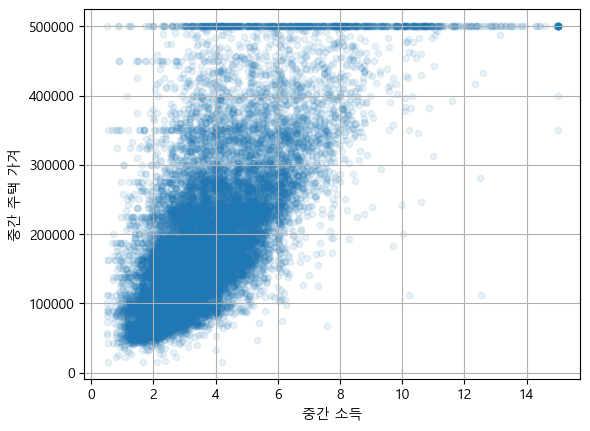

In [25]:
housing.plot(kind = 'scatter', x = 'median_income', y = 'median_house_value', grid = True, alpha = 0.1);

plt.xlabel('중간 소득');
plt.ylabel('중간 주택 가겨');

## 특성 조합으로 실험하기

In [26]:
housing['rooms_per_house'] = housing['total_rooms'] / housing['households'] # 집의 방의 수
housing['bedrooms_ratio'] = housing['total_bedrooms'] / housing['total_rooms'] # 침실 비율
housing['population_per_house'] = housing['population'] / housing['households'] # 가구 당 인원 수

In [27]:
corr_marrix = housing.corr(numeric_only = True)
corr_marrix['median_house_value'].sort_values(ascending = False)

median_house_value      1.000000
median_income           0.688380
rooms_per_house         0.143663
total_rooms             0.137455
housing_median_age      0.102175
households              0.071426
total_bedrooms          0.054635
population             -0.020153
population_per_house   -0.038224
longitude              -0.050859
latitude               -0.139584
bedrooms_ratio         -0.256397
Name: median_house_value, dtype: float64

# 머신러닝 알고리즘을 위한 데이터 준비

In [28]:
housing = strat_train_set.drop('median_house_value', axis = 1) # 예측하기 위한 변수
housing_labels = strat_train_set['median_house_value'].copy() # 예측할 변수(주택 가격)

## 데이터 정제

### 결측치 제거

1. 열 제거
2. 결측치만 제거
3. 어떠한 값으로 대체

In [29]:
housing.isnull().sum() # total_bedrooms의 결측치 처리하기

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        168
population              0
households              0
median_income           0
ocean_proximity         0
dtype: int64

In [30]:
# 각 옵션에 housing을 오염시키지 않기 위해 복사본을 사용하여 작성한다.
# 각 옵션의 출력을 확인하지만 NaN 값을 담고 있는 행은 필터링 한다.

# 아래 코드셀 실행
null_rows_idx = housing.isnull().any(axis=1)
housing.loc[null_rows_idx].head()


# # 아래 코드셀 실행
housing_option1 = housing.copy()
housing_option1.dropna(subset=["total_bedrooms"], inplace=True)  # 옵션 1
housing_option1.loc[null_rows_idx].head()


# # 아래 코드셀 실행
housing_option2 = housing.copy()
housing_option2.drop("total_bedrooms", axis=1, inplace=True)  # 옵션 2
housing_option2.loc[null_rows_idx].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,NaN,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,NaN,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,NaN,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,NaN,375.0,183.0,9.8020,<1H OCEAN


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
14452,-120.67,40.50,15.0,5343.0,2503.0,902.0,3.5962,INLAND
18217,-117.96,34.03,35.0,2093.0,1755.0,403.0,3.4115,<1H OCEAN
11889,-118.05,34.04,33.0,1348.0,1098.0,257.0,4.2917,<1H OCEAN
20325,-118.88,34.17,15.0,4260.0,1701.0,669.0,5.1033,<1H OCEAN
14360,-117.87,33.62,8.0,1266.0,375.0,183.0,9.8020,<1H OCEAN


In [31]:
# 방법 1
# housing.drop('total_bedrooms', axis = 1)

# 방법 2
# housing.dropna(subset = ['total_bedrooms'])

# 방법 3
median = housing['total_bedrooms'].median()
housing['total_bedrooms'].fillna(median, inplace = True)

In [32]:
housing.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
dtype: int64

In [33]:
# 다른 방법
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = 'median') # 모든 수치형 column에 대해 null값을 median으로 대체한다

# 중간값은 수치형 특성에만 계산될 수 있기 때문에 수치 특성만 가진 데이터 복사본 생성
housing_num = housing.select_dtypes(include = [np.number])

# 훈련 데이터에 적용
imputer.fit(housing_num)

imputer.statistics_
housing_num.median().values

# 학습된 imputer 객체를 사용해 훈련 세트에서 누락된 값을 학습한 중간값으로 바꿀 수 있다
X = imputer.transform(housing_num)

SimpleImputer(strategy='median')

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [34]:
imputer.feature_names_in_

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype=object)

In [35]:
housing_tr = pd.DataFrame(X, columns = housing_num.columns,
                          index = housing_num.index)

housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292


## 텍스트와 범주형 특성 다루기

In [36]:
housing_cat = housing[['ocean_proximity']]
housing_cat.head()

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN


### OrdinalEncoder

In [37]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [38]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

### OneHotEncoder

In [39]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_ohe = cat_encoder.fit_transform(housing_cat)


housing_cat_ohe

<16512x5 sparse matrix of type '<class 'numpy.float64'>'
	with 16512 stored elements in Compressed Sparse Row format>

In [40]:
housing_cat_ohe.toarray()
housing_cat_ohe.todense()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

matrix([[0., 0., 0., 1., 0.],
        [1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        ...,
        [0., 0., 0., 0., 1.],
        [1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.]])

In [41]:
cat_encoder.categories_ 

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

### get_dummies

In [42]:
df_test = pd.DataFrame({'ocean_proximity' : ['INLAND', 'NEAR BAY']})
pd.get_dummies(df_test)

cat_encoder.transform(df_test).toarray()

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

### ohe는 예외를 처리함

In [43]:
df_test_unknown = pd.DataFrame({'ocean_proximity' : ['<2H OCEAN', 'ISLAND']})
pd.get_dummies(df_test_unknown)

cat_encoder.handle_unknown = 'ignore'
cat_encoder.transform(df_test).toarray()

,ocean_proximity_<2H OCEAN,ocean_proximity_ISLAND
0,True,False
1,False,True


array([[0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [44]:
cat_encoder.feature_names_in_

cat_encoder.get_feature_names_out()

array(['ocean_proximity'], dtype=object)

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [45]:
df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown).todense(),
                         columns = cat_encoder.get_feature_names_out(),
                         index = df_test_unknown.index)

df_output

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0


## 특성 스케일과 변환

### MinMaxScaler

In [46]:
from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler(feature_range = (-1, 1))
housing_num_mms = mm_scaler.fit_transform(housing_num)

housing_num_mms

array([[-0.60851927,  0.11702128,  1.        , ..., -0.80701754,
        -0.61433638, -0.7794789 ],
       [ 0.21095335, -0.66170213,  0.52941176, ..., -0.91866029,
        -0.86708979, -0.22929339],
       [-0.51926978,  0.23617021,  0.25490196, ..., -0.93141946,
        -0.92458466, -0.73336919],
       ...,
       [ 0.47870183, -0.99148936, -0.52941176, ..., -0.65513434,
        -0.71663244, -0.50873781],
       [ 0.20689655, -0.6787234 ,  0.41176471, ..., -0.78873758,
        -0.68751167, -0.49716556],
       [-0.60649087,  0.08723404,  0.68627451, ..., -0.91669734,
        -0.92122457, -0.61608805]])

### StandardScaler


In [47]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_stds = std_scaler.fit_transform(housing_num)

housing_num_stds

array([[-1.42303652,  1.0136059 ,  1.86111875, ...,  0.13746004,
         1.39481249, -0.93649149],
       [ 0.59639445, -0.702103  ,  0.90762971, ..., -0.69377062,
        -0.37348471,  1.17194198],
       [-1.2030985 ,  1.27611874,  0.35142777, ..., -0.78876841,
        -0.77572662, -0.75978881],
       ...,
       [ 1.25620853, -1.42870103, -1.23772062, ...,  1.26829911,
         0.67913534,  0.1010487 ],
       [ 0.58639727, -0.73960483,  0.66925745, ...,  0.27356264,
         0.88286825,  0.14539615],
       [-1.41803793,  0.94797769,  1.22545939, ..., -0.67915557,
        -0.75221898, -0.31034135]])

In [48]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[['housing_median_age']], [[35]], gamma = 0.1)
age_simil_35

array([[2.81118530e-13],
       [8.20849986e-02],
       [6.70320046e-01],
       ...,
       [9.55316054e-22],
       [6.70320046e-01],
       [3.03539138e-04]])

### target값(median_income) 변환

In [49]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[['median_income']], scaled_labels) # x_train : housing[['median_income']], y_train : scaled_labels

LinearRegression()

In [50]:
some_new_data = housing[['median_income']].iloc[:5]  # 새로운 데이터라 가정

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions) # inverse_transform : 원본 스케일로 되돌리기

predictions

array([[131997.15275877],
       [299359.35844434],
       [146023.37185694],
       [138840.33653057],
       [192016.61557639]])

In [51]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                   transformer = StandardScaler())

model.fit(housing[['median_income']], housing_labels)
predictions = model.predict(some_new_data)

predictions

TransformedTargetRegressor(regressor=LinearRegression(),
                           transformer=StandardScaler())

array([131997.15275877, 299359.35844434, 146023.37185694, 138840.33653057,
       192016.61557639])

## 사용자 정의 변환기

In [52]:
# 로그 변환기 만들기

from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func = np.exp)
log_pop = log_transformer.transform(housing[['population']])

In [53]:
# 가우스 RBF 유사도를 계산하는 변환기를 다음과 같이 만들기

rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args = dict(Y = [[35.]], gamma = 0.1))

age_simil_35 = rbf_transformer.transform(housing[['housing_median_age']])

In [54]:
# 두 개의 특성을 가진 배열을 전달하면 유사도를 측정하기 위해 2D 거리를 계산

sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args = dict(Y = [sf_coords], gamma = 0.1))

sf_simil = sf_transformer.transform(housing[['latitude', 'longitude']])

In [55]:
# 첫 번째 입력 특5성과 두 번재 특성 사이의 비율을 계산

ratio_transformer = FunctionTransformer(lambda X: X[:, [0]] / X[:, [1]])
ratio_transformer.transform(np.array([[1., 2.], [3., 4.]]))

array([[0.5 ],
       [0.75]])

In [56]:
# StandardScaler와 비슷하게 동작하는 사용자 정의 변환기

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted

class StandardScalerClone(BaseEstimator, TransformerMixin):
    def __init__(self, with_mean = True): # args나 **kwargs를 사용하지 않는다
        self.with_mean = with_mean
        
    def fit(self, X, y = None): # 사용하지 않더라도 y는 필수 입력
        X = check_array(X) # X가 부동소수점 배열인지 확인
        self.mean_ = X.mean(axis = 0)
        self.scale_ = X.std(axis = 0)        
        self.n_features_in_ = X.shape[1] # 모든 추정기는 fit()에서 이를 저장
        return self # 항상 self를 반환
    
    def transfirm(self, X):
        check_is_fitted(self) # 훈련으로 학습된 속성이 있는지 확인
        X = check_array(X)
        assert self.n_features_in_ == X.shape[1]
        if self.with_mean:
            X = X - self.mean_
        return X / self.scale_

In [57]:
# 하나의 사용자 변환기가 구현 안에서 다른 추정기를 사용
# 각 샘플이 클럿그터 중심과 얼마나 유사한지 측정

from sklearn.cluster import KMeans

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters = 10, gamma = 1.0, random_state = None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state
        
    def fit(self, X, y = None, sample_weight = None):
        self.kmeans_ = KMeans(self.n_clusters, random_state = self.random_state)
        self.kmeans_.fit(X, sample_weight = sample_weight)
        return self
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma = self.gamma)
    
    def get_feature_names_out(self, names = None):
        return [f'클러스터 {i} 유사도' for i in range(self.n_clusters)]

In [58]:
cluster_simil = ClusterSimilarity(n_clusters = 10, gamma = 1., random_state = 42)
similarities = cluster_simil.fit_transform(housing[['latitude', 'longitude']],
                                           sample_weight = housing_labels)

In [59]:
similarities[:3].round(2)

array([[0.08, 0.  , 0.6 , 0.  , 0.  , 0.99, 0.  , 0.  , 0.  , 0.14],
       [0.  , 0.99, 0.  , 0.04, 0.  , 0.  , 0.11, 0.  , 0.63, 0.  ],
       [0.44, 0.  , 0.3 , 0.  , 0.  , 0.7 , 0.  , 0.01, 0.  , 0.29]])

## 변환 파이프라인

In [68]:
# 다른 방법
from sklearn.pipeline import make_pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy = 'madian'), StandardScaler())

In [69]:
# 수치 특성에서 누란된 값을 대체하고 스케일을 조정하는 간단한 파이프라인

from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy = 'median')),
    ('standardize', StandardScaler())
])

In [70]:
# 파이프라인의 fit_trasnform() 메서드 출력

housing_num_prepared = num_pipeline.fit_transform(housing_num)
housing_num_prepared[:2].round(2)

array([[-1.42,  1.01,  1.86,  0.31,  1.37,  0.14,  1.39, -0.94],
       [ 0.6 , -0.7 ,  0.91, -0.31, -0.44, -0.69, -0.37,  1.17]])

In [71]:
df_housing_num_prepared = pd.DataFrame(
    housing_num_prepared, columns = num_pipeline.get_feature_names_out(),
    index =housing_num.index)

In [72]:
from sklearn.compose import ColumnTransformer

num_attribs = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
               'population', 'households', 'median_income']
cat_attribs = ['ocean_proximity']

cat_pipeline = make_pipeline(
    SimpleImputer(strategy = 'most_frequent'),
    OneHotEncoder(handle_unknown = 'ignore'))

preprocessing = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', cat_pipeline, cat_attribs)
])

In [73]:
from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include = np.number)),
    (cat_pipeline, make_column_selector(dtype_include = object)))

In [74]:
housing_prepared = preprocessing.fit_transform(housing)

In [75]:
preprocessing.get_feature_names_out()

array(['pipeline-1__longitude', 'pipeline-1__latitude',
       'pipeline-1__housing_median_age', 'pipeline-1__total_rooms',
       'pipeline-1__total_bedrooms', 'pipeline-1__population',
       'pipeline-1__households', 'pipeline-1__median_income',
       'pipeline-2__ocean_proximity_<1H OCEAN',
       'pipeline-2__ocean_proximity_INLAND',
       'pipeline-2__ocean_proximity_ISLAND',
       'pipeline-2__ocean_proximity_NEAR BAY',
       'pipeline-2__ocean_proximity_NEAR OCEAN'], dtype=object)

In [76]:
def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ['raito']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy = 'median'),
        FunctionTransformer(column_ratio, feature_names_out = ratio_name),
        StandardScaler())

log_pipeline = make_pipeline(
    SimpleImputer(strategy = 'median'),
    FunctionTransformer(np.log, feature_names_out = 'one-to-one'),
    StandardScaler())
cluster_simil = ClusterSimilarity(n_clusters = 10, gamma = 1., random_state = 42)
default_num_pipeline = make_pipeline(SimpleImputer(strategy = 'median'),
                                     StandardScaler())
preprocessing = ColumnTransformer([
    ('bedrooms', ratio_pipeline(), ['total_bedrooms', 'total_rooms']),
    ('rooms_per_house', ratio_pipeline(), ['total_rooms', 'households']),
    ('pepole_per_house', ratio_pipeline(), ['population', 'households']),
    ('log', log_pipeline, ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
    ('geo', cluster_simil, ['latitude', 'longitude']),
    ('cat', cat_pipeline, make_column_selector(dtype_include = object))
], remainder = default_num_pipeline)

In [77]:
housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape
preprocessing.get_feature_names_out()

(16512, 24)

array(['bedrooms__raito', 'rooms_per_house__raito',
       'pepole_per_house__raito', 'log__total_bedrooms',
       'log__total_rooms', 'log__population', 'log__households',
       'log__median_income', 'geo__클러스터 0 유사도', 'geo__클러스터 1 유사도',
       'geo__클러스터 2 유사도', 'geo__클러스터 3 유사도', 'geo__클러스터 4 유사도',
       'geo__클러스터 5 유사도', 'geo__클러스터 6 유사도', 'geo__클러스터 7 유사도',
       'geo__클러스터 8 유사도', 'geo__클러스터 9 유사도',
       'cat__ocean_proximity_<1H OCEAN', 'cat__ocean_proximity_INLAND',
       'cat__ocean_proximity_ISLAND', 'cat__ocean_proximity_NEAR BAY',
       'cat__ocean_proximity_NEAR OCEAN', 'remainder__housing_median_age'],
      dtype=object)

# 모델 선택과 훈련

## 훈련 세트에서 훈련하고 평가하기

In [78]:
from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000...
                                                   'median_income']),
                                                 ('geo',
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000248DFD11890>)])),
                ('linearregression', LinearRegression())])

In [79]:
housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(2)
housing_labels.iloc[:5].values

array([242761.81, 375862.79, 127480.98,  99355.3 , 324610.74])

array([458300., 483800., 101700.,  96100., 361800.])

In [80]:
from sklearn.metrics import mean_squared_error
lin_rmse = mean_squared_error(housing_labels, housing_predictions,

                              squared = False)
lin_rmse

68647.95686706701

In [81]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state = 42))
tree_reg.fit(housing, housing_labels)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x000...
                                                  ClusterSimilarity(random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000248DFD11890>)])),
                ('decisiontreeregressor',
                 DecisionTreeRegressor(random_state=42))])

In [82]:
housing_predictions = tree_reg.predict(housing)
tree_rmse = mean_squared_error(housing_labels, housing_predictions,
                               squared = False)

tree_rmse

0.0

## 교차 검정으로 평가하기

In [83]:
from sklearn.model_selection import cross_val_score

tree_rmses = -cross_val_score(tree_reg, housing, housing_labels,
                              scoring = 'neg_root_mean_squared_error', cv = 10)

In [84]:
pd.Series(tree_rmses).describe()

count       10.000000
mean     67146.519731
std       2125.705276
min      63925.253106
25%      65947.172685
50%      66609.261581
75%      68074.018403
max      70664.635833
dtype: float64

In [85]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state = 43))

rf_rmses = -cross_val_score(rf_reg, housing, housing_labels,
                          scoring = 'neg_root_mean_squared_error', cv = 10)

In [86]:
pd.Series(rf_rmses).describe()

count       10.000000
mean     46950.444882
std       1123.782975
min      45295.672670
25%      46201.978808
50%      47062.833941
75%      47315.418983
max      49367.513245
dtype: float64

# 모델 미세 튜닝

## 그리드 서치

In [87]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest', RandomForestRegressor(random_state = 42))
])

param_grid = [
    {'preprocessing__geo__n_clusters' : [5, 8, 10],
     'random_forest__max_features' : [4, 6, 8]},
    {'preprocessing__geo__n_clusters' : [10, 15],
     'random_forest__max_features' : [6, 8, 10]}
]

grid_search = GridSearchCV(full_pipeline, param_grid, cv = 3, scoring = 'neg_root_mean_squared_error')
grid_search.fit(housing, housing_labels)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                     SimpleImputer(strategy='median')),
                                                                                    ('standardscaler',
                                                                                     StandardScaler())]),
                                                          transformers=[('bedrooms',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('functiontransformer',
                                                                                          FunctionTransformer(feature_names_out=<f...
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x00000248DFD11890>)])),
                                       ('random_forest',
                                        RandomForestRegressor(random_state=42))]),
             param_grid=[{'preprocessing__geo__n_clusters': [5, 8, 10],
                          'random_forest__max_features': [4, 6, 8]},
                         {'preprocessing__geo__n_clusters': [10, 15],
                          'random_forest__max_features': [6, 8, 10]}],
             scoring='neg_root_mean_squared_error')

In [88]:
# 최상의 하이퍼파라미터 조합
print(str(full_pipeline.get_params().keys())[:1000] + '...')

dict_keys(['memory', 'steps', 'verbose', 'preprocessing', 'random_forest', 'preprocessing__n_jobs', 'preprocessing__remainder__memory', 'preprocessing__remainder__steps', 'preprocessing__remainder__verbose', 'preprocessing__remainder__simpleimputer', 'preprocessing__remainder__standardscaler', 'preprocessing__remainder__simpleimputer__add_indicator', 'preprocessing__remainder__simpleimputer__copy', 'preprocessing__remainder__simpleimputer__fill_value', 'preprocessing__remainder__simpleimputer__keep_empty_features', 'preprocessing__remainder__simpleimputer__missing_values', 'preprocessing__remainder__simpleimputer__strategy', 'preprocessing__remainder__standardscaler__copy', 'preprocessing__remainder__standardscaler__with_mean', 'preprocessing__remainder__standardscaler__with_std', 'preprocessing__remainder', 'preprocessing__sparse_threshold', 'preprocessing__transformer_weights', 'preprocessing__transformers', 'preprocessing__verbose', 'preprocessing__verbose_feature_names_out', 'prepr

In [89]:
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [90]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('bedrooms',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('functiontransformer',
                                                                   FunctionTransformer(feature_names_out=<function ratio_name at 0x0000024...
                                                  ClusterSimilarity(n_clusters=15,
                                                                    random_state=42),
                                                  ['latitude', 'longitude']),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000248E80C5AD0>)])),
                ('random_forest',
                 RandomForestRegressor(max_features=6, random_state=42))])

In [91]:
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res.sort_values(by = 'mean_test_score', ascending = False, inplace = True)
[...]
cv_res.head()

[Ellipsis]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,12.308108,0.036778,0.126325,0.000951,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-43426.405313,-43753.147171,-44532.567341,-43904.039941,464.022327,1
13,15.940059,0.058520,0.125332,0.000471,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-44073.089146,-44204.924326,-44981.685091,-44419.899521,400.871882,2
14,19.568368,0.081044,0.125324,0.000465,15,10,"{'preprocessing__geo__n_clusters': 15, 'random...",-44328.010955,-44496.254950,-45212.222299,-44678.829401,383.368837,3
7,12.545808,0.058561,0.124325,0.000947,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44211.527321,-44628.321123,-45805.359075,-44881.735840,674.902057,4
9,12.518899,0.056195,0.124971,0.000471,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44211.527321,-44628.321123,-45805.359075,-44881.735840,674.902057,4


## 랜덤 서치

In [94]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {'preprocessing__geo__n_clusters' : randint(low = 3, high = 50),
                  'random_forest__max_features' : randint(low = 2, high = 20)}

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions = param_distribs, n_iter = 10, cv = 3,
    scoring = 'neg_root_mean_squared_error', random_state = 42)

rnd_search.fit(housing, housing_labels)

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                                                           SimpleImputer(strategy='median')),
                                                                                          ('standardscaler',
                                                                                           StandardScaler())]),
                                                                transformers=[('bedrooms',
                                                                               Pipeline(steps=[('simpleimputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('functiontransformer',
                                                                                                FunctionTransformer(feature_names_...
                                             ('random_forest',
                                              RandomForestRegressor(random_state=42))]),
                   param_distributions={'preprocessing__geo__n_clusters': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000248E815F390>,
                                        'random_forest__max_features': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000248DFCD4110>},
                   random_state=42, scoring='neg_root_mean_squared_error')

## 앙상블 방법

## 최상의 모델과 오차 분석

In [96]:
final_model = rnd_search.best_estimator_
feature_importances = final_model['random_forest'].feature_importances_
feature_importances.round(2)

array([0.06, 0.06, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.01, 0.02,
       0.04, 0.01, 0.  , 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.  ,
       0.01, 0.  , 0.01, 0.02, 0.02, 0.01, 0.01, 0.01, 0.03, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.  , 0.01, 0.01, 0.02, 0.01, 0.01, 0.01,
       0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

In [97]:
sorted(zip(feature_importances,
           final_model['preprocessing'].get_feature_names_out()),
           reverse = True)

[(0.1898423270105783, 'log__median_income'),
 (0.07709175866873944, 'cat__ocean_proximity_INLAND'),
 (0.06455488601956336, 'bedrooms__raito'),
 (0.056936146643377976, 'rooms_per_house__raito'),
 (0.0490294770805355, 'pepole_per_house__raito'),
 (0.03807069074492323, 'geo__클러스터 3 유사도'),
 (0.025643913400094472, 'geo__클러스터 22 유사도'),
 (0.02179127543243723, 'geo__클러스터 17 유사도'),
 (0.021575251507503695, 'geo__클러스터 6 유사도'),
 (0.017868654556924362, 'geo__클러스터 2 유사도'),
 (0.017431400050755975, 'geo__클러스터 32 유사도'),
 (0.015981159400591683, 'geo__클러스터 18 유사도'),
 (0.014888464257396877, 'geo__클러스터 40 유사도'),
 (0.014488389218107146, 'geo__클러스터 43 유사도'),
 (0.014252940099964142, 'geo__클러스터 7 유사도'),
 (0.014038173319370725, 'geo__클러스터 21 유사도'),
 (0.013846025114732161, 'geo__클러스터 38 유사도'),
 (0.013625709964722737, 'geo__클러스터 34 유사도'),
 (0.013547297167034428, 'geo__클러스터 41 유사도'),
 (0.01290008902606692, 'geo__클러스터 24 유사도'),
 (0.012620908145579916, 'geo__클러스터 10 유사도'),
 (0.011621275372313349, 'remainder__housing

## 테스트 세트로 시스템 평가하기

In [98]:
X_test = strat_test_set.drop('median_house_value', axis = 1)
y_test = strat_test_set['median_house_value'].copy()

final_predictions = final_model.predict(X_test)

final_rmse = mean_squared_error(y_test, final_predictions, squared = False)
final_rmse

41549.20158097943

In [100]:
X_test

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
3905,-121.95,37.11,21.0,2387.0,357.0,913.0,341.0,7.7360,<1H OCEAN
16821,-118.01,33.89,36.0,1589.0,265.0,804.0,272.0,4.6354,<1H OCEAN
2900,-118.18,33.74,30.0,5915.0,1750.0,2136.0,1503.0,4.0968,NEAR OCEAN
7193,-122.48,37.74,52.0,2166.0,423.0,1072.0,370.0,4.1310,NEAR OCEAN
13928,-122.39,37.78,5.0,1405.0,515.0,725.0,392.0,3.6037,NEAR BAY
...,...,...,...,...,...,...,...,...,...
12369,-124.16,40.79,46.0,3042.0,597.0,1206.0,541.0,2.1135,NEAR OCEAN
8707,-119.01,35.39,29.0,1820.0,459.0,1134.0,419.0,1.8289,INLAND
16634,-123.01,38.67,33.0,914.0,147.0,394.0,132.0,4.6875,<1H OCEAN
9779,-122.03,37.60,24.0,2077.0,383.0,1488.0,389.0,4.5721,NEAR BAY


In [99]:
from scipy import stats
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc = squared_errors.mean(),
                         scale = stats.sem(squared_errors)))

array([39395.35475927, 43596.76969025])